In [5]:
from mymodels import AlexNet, train, test_error, kCV
from dataUtils import *
from sklearn.model_selection import KFold
from torch.utils.data import Subset
from torch import nn,optim,save,load
import matplotlib.pyplot as plt
import time
from torch.cuda import synchronize

device = 'cuda'

In [2]:
model = AlexNet(dropout=0.041176470588235294)
model.to(device)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.000260626067537044)
epochs = 15
dataset = make_train_val_set()
all_loss = kCV(5,dataset,model,loss_fn,optimizer,epochs=epochs,batch_size=8)
save(model.state_dict(), 'models/alex_net.pth')

FOLD 0
EPOCH 1
	train loss:	 0.04079827073900913
	val. loss:	 0.03999953545458919
EPOCH 2
	train loss:	 0.03766154065283909
	val. loss:	 0.03817473385692099
EPOCH 3
	train loss:	 0.036608581784613695
	val. loss:	 0.046548981162510356
EPOCH 4
	train loss:	 0.03664536153237164
	val. loss:	 0.037409159231322764
EPOCH 5
	train loss:	 0.0356140304469665
	val. loss:	 0.03966418168821125
EPOCH 6
	train loss:	 0.036040561350314325
	val. loss:	 0.03720506127657635
EPOCH 7
	train loss:	 0.03550900050381921
	val. loss:	 0.03733701540670377
EPOCH 8
	train loss:	 0.035026343492434685
	val. loss:	 0.03689770969771305
EPOCH 9
	train loss:	 0.03513419217274439
	val. loss:	 0.03670907805540732
EPOCH 10
	train loss:	 0.03521969214756498
	val. loss:	 0.03657242612038948
EPOCH 11
	train loss:	 0.03514238173909466
	val. loss:	 0.03650049065068668
EPOCH 12
	train loss:	 0.03486927668415533
	val. loss:	 0.036189702577052674
EPOCH 13
	train loss:	 0.03511177301163339
	val. loss:	 0.036718778530781974
EPOCH 14

In [5]:
import json
filename = 'results/alexnet.json'
with open(filename, 'w') as fp:
        json.dump(all_loss, fp)

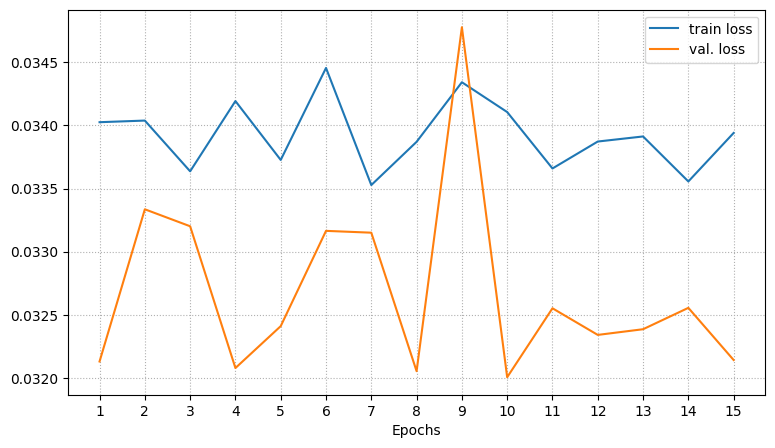

In [10]:
net = AlexNet()
net.load_state_dict(load('models/alex_net.pth',weights_only=True))
all_loss = load_json('results/alexnet.json')
plt.subplots(figsize=(9,5))
epochs = len(all_loss['all-loss'][0]['train'])
plt.plot(range(1,epochs+1),all_loss['all-loss'][-1]['train'],label='train loss')
plt.plot(range(1,epochs+1),all_loss['all-loss'][-1]['validation'],label='val. loss')
plt.xticks(range(1,epochs+1))
plt.legend()
plt.xlabel('Epochs')
plt.grid(linestyle='dotted')
plt.savefig('alexnet_loss.pdf',bbox_inches='tight', pad_inches=0)

In [3]:
cv = all_loss['CV-loss']
test = test_error(net,make_test_set())
validation = all_loss['all-loss'][-1]['validation'][-1]
train = all_loss['all-loss'][-1]['train'][-1]

print(f'train: {train}\nvalid.: {validation}\ntest: {test}\ncv: {cv}')

train: 0.03394068992187088
valid.: 0.03214134647491939
test: 0.03476559190379306
cv: 0.034890374114109696


In [7]:
testloader = DataLoader(
    make_test_set(), batch_size=4, shuffle=False, num_workers=2
)
net.eval()
total_time = 0
device = 'cuda'
net.to(device)
test_error(net,make_test_set(),device='cuda') #WARM UP
for data in testloader:
    x, area, ate, are = data
    x = x.to(device)
    area = area.to(device)
    ate = ate.to(device)
    are = are.to(device)
    synchronize()
    start_time = time.time()
    outputs = net(x,area)
    synchronize()
    end_time = time.time()
    total_time += (end_time-start_time)/len(data)
inf_time = total_time/len(testloader)
print(f'inference time GPU: {inf_time}')
total_time = 0
device = 'cpu'
net.to(device)
test_error(net,make_test_set(),device='cpu') #WARM UP
for data in testloader:
    x, area, ate, are = data
    x = x.to(device)
    area = area.to(device)
    ate = ate.to(device)
    are = are.to(device)
    synchronize()
    start_time = time.time()
    outputs = net(x,area)
    synchronize()
    end_time = time.time()
    total_time += (end_time-start_time)/len(data)
inf_time = total_time/len(testloader)
print(f'inference time CPU: {inf_time}')

inference time GPU: 0.0002394928329292385
inference time CPU: 0.005354185556543285


In [8]:
param_size = 0
for param in net.parameters():
    param_size += param.nelement() * param.element_size()
buffer_size = 0
for buffer in net.buffers():
    buffer_size += buffer.nelement() * buffer.element_size()

size_all_mb = (param_size + buffer_size) / 1024**2
print('model size: {:.3f}MB'.format(size_all_mb))

model size: 142.284MB
